In [3]:
import pickle as pkl
import numpy as np
import torch

In [4]:
with open('exported/first_vllm_response_async_worker_2259c1d2.pkl', 'rb') as f:
    vllm_resp = pkl.load(f)

with open('exported/first_training_batch_trainer_f7d82257.pkl', 'rb') as f:
    training_batch = pkl.load(f)


with open('exported/first_inference_batch_async_worker_2259c1d2.pkl', 'rb') as f:
    inference_batch = pkl.load(f)

print(inference_batch)
print(training_batch)
print(vllm_resp)


{'worker_id': '2259c1d2', 'prompt_token_ids': [[151644, 872, 198, 151652, 151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655

In [5]:
from transformers import AutoProcessor
processor = AutoProcessor.from_pretrained("Qwen/Qwen3-VL-2B-Instruct")

In [6]:
idx = 0
print('total number of prompts:', len(inference_batch['prompt_token_ids']))
curr_prompt = inference_batch['prompt_token_ids'][0]
print('len', len(curr_prompt), 'vllm input current prompt:', curr_prompt)
print('string version:', processor.decode(curr_prompt))
vllm_resp_prompt = vllm_resp['prompt_token_ids'][0]
print('len', len(vllm_resp_prompt), 'vllm output current prompt:', vllm_resp_prompt)
print('string version:', processor.decode(vllm_resp_prompt))


total number of prompts: 48
len 267 vllm input current prompt: [151644, 872, 198, 151652, 151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655

found match! 0
current prompt: <|im_start|>user
<|vision_start|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|>

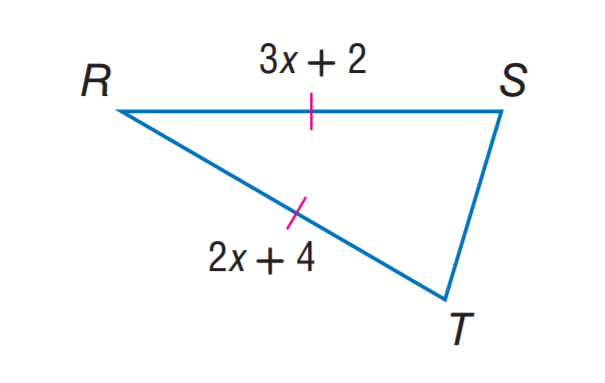

In [7]:
inf_resp = vllm_resp['response_ids'][0]
training_batch['sequences'].shape
training_input_seqs = training_batch['sequences']
resp_len = training_batch['loss_mask'].shape[1]
input_len = training_input_seqs.shape[1] - resp_len
training_input_seqs = training_input_seqs[:, :input_len]
for i, seq in enumerate(training_input_seqs):
    curr_inp = seq[-len(curr_prompt):]
    if (curr_inp == curr_prompt).all():
        print('found match!', i )
        model_rest = training_batch['sequences'][i, input_len:]
        corresponding_idx = i
        break
print('current prompt:', processor.decode(curr_inp))
print('rest:', processor.decode(model_rest))
print('inf resp:', processor.decode(inf_resp))
curr_img = inference_batch['multi_modal_data'][0]['image']
curr_img.show()

In [89]:
print((inf_resp == model_rest[:134]).all())
print((training_batch['rollout_logprobs'][0, :134] ==vllm_resp['response_logprobs'][0]).all())
training_batch.keys(), vllm_resp.keys(), inference_batch.keys()

True
True


(dict_keys(['trainer_id', 'global_step', 'sequences', 'attention_mask', 'loss_mask', 'response_mask', 'rollout_logprobs', 'metadata']),
 dict_keys(['worker_id', 'prompt_token_ids', 'response_ids', 'responses', 'stop_reasons', 'response_logprobs']),
 dict_keys(['worker_id', 'prompt_token_ids', 'sampling_params', 'multi_modal_data']))

In [91]:
from transformers import AutoModelForImageTextToText, AutoProcessor

# default: Load the model on the available device(s)
model = AutoModelForImageTextToText.from_pretrained(
    "Qwen/Qwen3-VL-2B-Instruct", #dtype=torch.bfloat16
)
model = model.cuda()


Loading weights:   0%|          | 0/625 [00:00<?, ?it/s]

In [99]:
img_inputs = processor.image_processor(curr_img)
for k, v in img_inputs.items():
    print(k, v.shape, type(v))
    img_inputs[k] = v.cuda()
print(type(training_batch['attention_mask'][0]))
print(type(training_batch['sequences'][0]))
model = model.eval().cuda()
with torch.no_grad():
    inp_ids = torch.from_numpy(training_batch['sequences'][0]).cuda().unsqueeze(0)
    attn_mask = torch.from_numpy(training_batch['attention_mask'][0]).cuda().unsqueeze(0)
    output = model.forward(input_ids=inp_ids, attention_mask=attn_mask, **img_inputs)

pixel_values torch.Size([912, 1536]) <class 'torch.Tensor'>
image_grid_thw torch.Size([1, 3]) <class 'torch.Tensor'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>


In [101]:
logits = output.logits
logits.shape

torch.Size([1, 1531, 151936])

In [2]:
import os
os.environ['VLLM_WORKER_MULTIPROC_METHOD'] = 'spawn'
from vllm import LLM
llm = LLM(
    model="Qwen/Qwen3-VL-2B-Instruct",
    max_model_len=4096,
)


INFO 01-29 00:38:43 [utils.py:263] non-default args: {'max_model_len': 4096, 'disable_log_stats': True, 'model': 'Qwen/Qwen3-VL-2B-Instruct'}
INFO 01-29 00:38:43 [model.py:530] Resolved architecture: Qwen3VLForConditionalGeneration
INFO 01-29 00:38:43 [model.py:1545] Using max model len 4096
INFO 01-29 00:38:43 [scheduler.py:229] Chunked prefill is enabled with max_num_batched_tokens=8192.
INFO 01-29 00:38:43 [vllm.py:630] Asynchronous scheduling is enabled.
INFO 01-29 00:38:43 [vllm.py:637] Disabling NCCL for DP synchronization when using async scheduling.
(EngineCore_DP0 pid=164889) INFO 01-29 00:38:50 [core.py:97] Initializing a V1 LLM engine (v0.14.1) with config: model='Qwen/Qwen3-VL-2B-Instruct', speculative_config=None, tokenizer='Qwen/Qwen3-VL-2B-Instruct', skip_tokenizer_init=False, tokenizer_mode=auto, revision=None, tokenizer_revision=None, trust_remote_code=False, dtype=torch.bfloat16, max_seq_len=4096, download_dir=None, load_format=auto, tensor_parallel_size=1, pipeline_p

Loading safetensors checkpoint shards:   0% Completed | 0/1 [00:00<?, ?it/s]
Loading safetensors checkpoint shards: 100% Completed | 1/1 [00:00<00:00,  1.80it/s]
Loading safetensors checkpoint shards: 100% Completed | 1/1 [00:00<00:00,  1.80it/s]
(EngineCore_DP0 pid=164889) 


(EngineCore_DP0 pid=164889) INFO 01-29 00:38:58 [default_loader.py:291] Loading weights took 0.69 seconds
(EngineCore_DP0 pid=164889) INFO 01-29 00:38:58 [gpu_model_runner.py:3905] Model loading took 4.31 GiB memory and 1.084250 seconds
(EngineCore_DP0 pid=164889) INFO 01-29 00:38:58 [gpu_model_runner.py:4715] Encoder cache will be initialized with a budget of 16384 tokens, and profiled with 1 image items of the maximum feature size.
(EngineCore_DP0 pid=164889) INFO 01-29 00:39:05 [backends.py:644] Using cache directory: /home/ray/.cache/vllm/torch_compile_cache/6d592f4c54/rank_0_0/backbone for vLLM's torch.compile
(EngineCore_DP0 pid=164889) INFO 01-29 00:39:05 [backends.py:704] Dynamo bytecode transform time: 5.74 s
(EngineCore_DP0 pid=164889) INFO 01-29 00:39:10 [backends.py:226] Directly load the compiled graph(s) for compile range (1, 8192) from the cache, took 0.880 s
(EngineCore_DP0 pid=164889) INFO 01-29 00:39:10 [monitor.py:34] torch.compile takes 6.62 s in total
(EngineCore_D

Capturing CUDA graphs (mixed prefill-decode, PIECEWISE): 100%|██████████| 51/51 [00:02<00:00, 22.69it/s]
Capturing CUDA graphs (decode, FULL): 100%|██████████| 35/35 [00:01<00:00, 24.34it/s]


(EngineCore_DP0 pid=164889) INFO 01-29 00:39:15 [gpu_model_runner.py:4856] Graph capturing finished in 4 secs, took 0.50 GiB
(EngineCore_DP0 pid=164889) INFO 01-29 00:39:15 [core.py:273] init engine (profile, create kv cache, warmup model) took 17.26 seconds
(EngineCore_DP0 pid=164889) INFO 01-29 00:39:16 [vllm.py:630] Asynchronous scheduling is enabled.
INFO 01-29 00:39:16 [llm.py:347] Supported tasks: ['generate']


In [29]:
dir(llm.input_processor.input_preprocessor.preprocess)
llm.input_processor.input_preprocessor.clear_mm_cache()
tokenized_out = llm.input_processor.input_preprocessor.preprocess(
    {
        "prompt": new_p,
        "multi_modal_data": {
            "image": curr_img
        }
    }
)
tokenized_out

AssertionError: Failed to apply prompt replacement for mm_items['image'][0]

In [9]:
dir(llm.input_processor.input_preprocessor)

['__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__sizeof__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 '_build_decoder_only_llm_inputs',
 '_build_enc_dec_llm_inputs',
 '_get_default_enc_dec_decoder_prompt',
 '_get_mm_processor',
 '_get_tokenization_kw',
 '_mm_processor',
 '_prepare_decoder_input_ids_for_generation',
 '_preprocess',
 '_process_decoder_only_prompt',
 '_process_embeds',
 '_process_encoder_decoder_prompt',
 '_process_multimodal',
 '_process_text',
 '_process_tokens',
 '_prompt_to_llm_inputs',
 '_split_enc_dec_mm_inputs',
 '_tokenize_prompt',
 '_truncate_inputs',
 'clear_mm_cache',
 'get_bos_token_id',
 'get_decoder_start_token_id',
 'get_eos_token_id',
 'get_tokenizer',
 'mm_cache_stats',
 'mm

In [28]:
curr_prompt
p = curr_prompt[1:3] + curr_prompt[233:]
# print(curr_prompt, processor.decode(curr_prompt))
new_p =  '<|im_start|> <|im_end|>' + processor.decode(p)
print(new_p)
print(processor.decode(p))

<|im_start|> <|im_end|>user
<image>Find $x$.  Output the thinking process in <think> </think> and final answer in <answer> </answer> tags.<|im_end|>
<|im_start|>assistant

user
<image>Find $x$.  Output the thinking process in <think> </think> and final answer in <answer> </answer> tags.<|im_end|>
<|im_start|>assistant



In [24]:
decoded =  processor.decode(p)
print(decoded)
processor.tokenizer.apply_chat_template(p, tokenize=False)

user
<image>Find $x$.  Output the thinking process in <think> </think> and final answer in <answer> </answer> tags.<|im_end|>
<|im_start|>assistant



''

In [31]:
curr_prompt
processor.tokenizer

Qwen2TokenizerFast(name_or_path='Qwen/Qwen3-VL-2B-Instruct', vocab_size=151643, model_max_length=262144, is_fast=True, padding_side='right', truncation_side='right', special_tokens={'eos_token': '<|im_end|>', 'pad_token': '<|endoftext|>', 'additional_special_tokens': ['<|im_start|>', '<|im_end|>', '<|object_ref_start|>', '<|object_ref_end|>', '<|box_start|>', '<|box_end|>', '<|quad_start|>', '<|quad_end|>', '<|vision_start|>', '<|vision_end|>', '<|vision_pad|>', '<|image_pad|>', '<|video_pad|>']}, clean_up_tokenization_spaces=False, added_tokens_decoder={
	151643: AddedToken("<|endoftext|>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	151644: AddedToken("<|im_start|>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	151645: AddedToken("<|im_end|>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	151646: AddedToken("<|object_ref_start|>", rstrip=False, lstrip=False, single_word=False, 

ERROR 01-29 02:00:58 [core_client.py:610] Engine core proc EngineCore_DP0 died unexpectedly, shutting down client.


In [40]:
from datasets import load_dataset
ds = load_dataset('parquet', data_files='/home/ray/data/geometry_3k/train-dev.parquet')

Generating train split: 0 examples [00:00, ? examples/s]

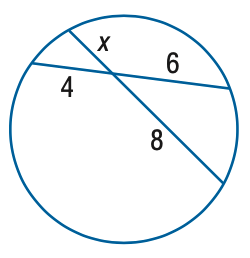

In [50]:
from PIL import Image
import io
im = Image.open(io.BytesIO(ds['train'][0]['prompt'][0]['content'][0]['image']['bytes']))
im.show()

In [52]:
ds['train'][0]['prompt']

[{'content': [{'image': {'bytes': b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHDR\x00\x00\x00\xfa\x00\x00\x01\x02\x08\x06\x00\x00\x00\xd7Z\xca\xfd\x00\x00\x01FiCCPICC Profile\x00\x00x\x9cc``\x12I,(\xc8aa``\xc8\xcd+)\nrwR\x88\x88\x8cR`\x7f\xc2\xc0\xcc \xcd\xc0\xcb\xc0\xc5\xc0\x96\x98\\\\\xe0\x18\x10\xe0\x03T\xc2\x00\xa3Q\xc1\xb7k\x0c\x8c \xfa\xb2.\xc8,\xa1\xb4\x833\xb8\xe7<z\xa7\xce\x91\x17\x91\xdf\xe8\x99\x8d\xa9\x1e\x05p\xa5\xa4\x16\'\x03\xe9?@\x9c\x9e\\PT\xc2\xc0\xc0\x98\x02d+\x97\x97\x14\x80\xd8\x1d@\xb6H\x11\xd0Q@\xf6\x1c\x10;\x1d\xc2\xde\x00b\'A\xd8G\xc0jB\x82\x9c\x81\xec\x1b@\xb6@rF"\xd0\x0c\xc6\x17@\xb6N\x12\x92x:\x12\x1bj/\x08\xf0\xba\xb8\xfa\xf8(\x04\xbb\x1a\x99\x1bZz\x10p/\xc9\xa0$\xb5\xa2\x04D;\xe7\x17T\x16e\xa6g\x94(8\x02C)U\xc13/YOG\xc1\xc8\xc0\xc8\x80\x81\x01\x14\xe6\x10\xd5\x9fo\x80\xc3\x92Q\x8c\x03!\x96\xd2\xce\xc0`\xac\x05\x14\xe4B\x88e=a`\xd83\x9d\x81A\xf0\x14BL\x1d\x18\xd6\x02v\x0c\x0c\x07"\x0b\x12\x8b\x12\xe1\x0e`\xfc\xc6R\x9cfl\x04asog``\x9d\xf6\xff\xff\xe7p\x06\x06vM\x06\x8